In [1]:
from IPython.display import HTML
HTML('''<style>.jp-Cell-inputWrapper, .input { margin-top: 0.5em; }</style>''')

# Notebook 03 — Feature Selection (Stacked Dataset)
## ENGG2112 Project MODR

Apply six feature selection methods to the stacked multi-disease dataset (357 rows). Identify which features should enter the final ML models in Notebooks 04-08.

### What changed from previous version
- Operates on `master_stacked.csv` (357 rows = flu + COVID + RSV stacked) instead of `master_counties.csv` (141 flu only)
- Includes 6 PLACES comorbidity/healthcare features that weren't selected previously due to bug in feature list
- Adds `disease` (one-hot) and `state` (one-hot) as categorical features
- Uses **`StratifiedGroupKFold(groups=fips)`** to prevent the same county appearing in train and test (county now appears up to 3× across diseases)

### Methods (5 ranking + 1 diagnostic)
| Type | Method |
|---|---|
| Filter | Pearson correlation |
| Filter | Spearman correlation |
| Filter | Mutual Information |
| Filter | VIF (diagnostic only — drops, doesn't rank) |
| Embedded | LASSO (LogisticRegressionCV with L1) |
| Embedded | Random Forest permutation importance |
| Wrapper | Recursive Feature Elimination CV |

### Consensus rule
Top 8 of 5 ranking methods (broader than before because we have more candidate features). Disease + state dummies are locked in by domain override.

## 1. Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV, mutual_info_classif
from sklearn.model_selection import StratifiedKFold
from sklearn.inspection import permutation_importance
from statsmodels.stats.outliers_influence import variance_inflation_factor

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'

plt.rcParams.update({
    'figure.figsize': (12, 6), 'axes.titlesize': 13, 'axes.labelsize': 11,
    'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False
})
sns.set_style('whitegrid')

master = pd.read_csv(PROCESSED_DIR / 'master_stacked.csv', dtype={'fips': str, 'state_fips': str})
print(f'Stacked dataset: {master.shape}')
print(f'Disease × state: \n{master.groupby(["disease", "state"]).size()}')

# All candidate demographic + PLACES features
CANDIDATE_FEATURES = [
    # Demographic
    'pop_density_per_sqmi', 'median_age', 'pct_elderly',
    'avg_household_size',
    'median_income', 'poverty_rate', 'unemployment_rate',
    'public_transport_pct',
    'pct_bachelors_plus',
    'pct_non_white', 'pct_foreign_born',
    # PLACES
    'pct_checkup', 'pct_obesity', 'pct_diabetes', 'pct_copd', 'pct_chd', 'pct_csmoking',
]
print(f'\nCandidate features: {len(CANDIDATE_FEATURES)}')

Stacked dataset: (357, 39)
Disease × state: 
disease  state
COVID    CT        8
         DE        3
         NY       62
         PA       67
FLU      CT        9
         DE        3
         NY       62
         PA       67
RSV      CT        9
         PA       67
dtype: int64

Candidate features: 17


## 2. Build Feature Matrix

In [3]:
X_raw = master[CANDIDATE_FEATURES].copy()
y = master['outbreak'].astype(int).values
groups = master['fips'].values  # for GroupKFold

# Standardise
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=CANDIDATE_FEATURES, index=X_raw.index)

print(f'Feature matrix: {X_scaled.shape}')
print(f'Target balance: {y.sum()}/{len(y)} = {y.mean():.1%}')
print(f'Unique counties (groups): {len(set(groups))}')

# CV strategy — stratified by outbreak, grouped by county
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f'CV: 5-fold StratifiedKFold (Notebook 04 will use StratifiedGroupKFold for final evaluation)')

Feature matrix: (357, 17)
Target balance: 93/357 = 26.1%
Unique counties (groups): 149
CV: 5-fold StratifiedKFold (Notebook 04 will use StratifiedGroupKFold for final evaluation)


## 3. Filter Methods

In [4]:
pearson = X_raw.apply(lambda c: c.corr(pd.Series(y), method='pearson'))
spearman = X_raw.apply(lambda c: c.corr(pd.Series(y), method='spearman'))
mi_scores = pd.Series(mutual_info_classif(X_scaled, y, random_state=42), index=CANDIDATE_FEATURES)

filter_df = pd.DataFrame({
    'pearson_abs': pearson.abs().round(3),
    'spearman_abs': spearman.abs().round(3),
    'mutual_info': mi_scores.round(3),
}).sort_values('mutual_info', ascending=False)
print('Filter scores (sorted by MI):\n')
print(filter_df.to_string())

filter_ranks = pd.DataFrame({
    'pearson_rank': filter_df['pearson_abs'].rank(ascending=False).astype(int),
    'spearman_rank': filter_df['spearman_abs'].rank(ascending=False).astype(int),
    'mi_rank': filter_df['mutual_info'].rank(ascending=False).astype(int),
}, index=filter_df.index)

Filter scores (sorted by MI):

                      pearson_abs  spearman_abs  mutual_info
pct_copd                    0.078         0.049        0.123
median_income               0.125         0.057        0.121
unemployment_rate           0.068         0.043        0.115
pct_foreign_born            0.261         0.157        0.114
pct_obesity                 0.065         0.010        0.105
pop_density_per_sqmi        0.139         0.131        0.103
pct_checkup                 0.031         0.030        0.091
pct_elderly                 0.119         0.104        0.090
avg_household_size          0.256         0.180        0.086
pct_non_white               0.194         0.135        0.086
public_transport_pct        0.215         0.072        0.077
pct_chd                     0.075         0.064        0.055
poverty_rate                0.030         0.022        0.053
pct_csmoking                0.066         0.042        0.049
pct_diabetes                0.078         0.081       

## 4. VIF Pruning

In [5]:
def compute_vif(df):
    X = df.values.astype(float)
    return pd.Series([variance_inflation_factor(X, i) for i in range(X.shape[1])], index=df.columns)

remaining = list(CANDIDATE_FEATURES)
vif_history = []
while True:
    df_iter = X_scaled[remaining]
    vifs = compute_vif(df_iter)
    if vifs.max() <= 10 or len(remaining) <= 2:
        break
    drop = vifs.idxmax()
    vif_history.append({'iter': len(vif_history)+1, 'dropped': drop, 'vif': round(vifs.max(), 1)})
    remaining.remove(drop)

print(f'VIF dropped {len(vif_history)} features:')
for h in vif_history:
    print(f'  {h["iter"]}: {h["dropped"]} (VIF={h["vif"]})')
print(f'\n{len(remaining)} features pass VIF<10:')
print(compute_vif(X_scaled[remaining]).round(1).to_string())

VIF dropped 4 features:
  1: pct_chd (VIF=46.4)
  2: pct_copd (VIF=24.5)
  3: pct_elderly (VIF=18.0)
  4: pct_foreign_born (VIF=16.2)

13 features pass VIF<10:
pop_density_per_sqmi    6.0
median_age              4.9
avg_household_size      3.2
median_income           9.9
poverty_rate            4.3
unemployment_rate       2.0
public_transport_pct    9.9
pct_bachelors_plus      8.7
pct_non_white           7.2
pct_checkup             2.0
pct_obesity             3.6
pct_diabetes            8.0
pct_csmoking            7.2


## 5. LASSO

In [6]:
lasso = LogisticRegressionCV(
    Cs=10, cv=cv, penalty='l1', solver='saga', class_weight='balanced',
    max_iter=5000, random_state=42, scoring='average_precision'
)
lasso.fit(X_scaled, y)
lasso_coefs = pd.Series(lasso.coef_[0], index=CANDIDATE_FEATURES)
print(f'LASSO best C: {lasso.C_[0]:.4f}')
print(f'LASSO coefs (sorted by |coef|):')
print(lasso_coefs.reindex(lasso_coefs.abs().sort_values(ascending=False).index).round(3).to_string())
lasso_rank = lasso_coefs.abs().rank(ascending=False).astype(int)

LASSO best C: 0.0464
LASSO coefs (sorted by |coef|):
avg_household_size      0.173
pct_foreign_born        0.169
pop_density_per_sqmi    0.000
pct_non_white           0.000
pct_chd                 0.000
pct_copd                0.000
pct_diabetes            0.000
pct_obesity             0.000
pct_checkup             0.000
pct_bachelors_plus      0.000
median_age              0.000
public_transport_pct    0.000
unemployment_rate       0.000
poverty_rate            0.000
median_income           0.000
pct_elderly             0.000
pct_csmoking            0.000


## 6. Random Forest Permutation Importance

RF permutation importance:
             feature  importance    std  rank
    pct_foreign_born      0.0118 0.0088     1
        pct_diabetes      0.0041 0.0044     2
   unemployment_rate      0.0021 0.0046     3
         pct_checkup      0.0021 0.0035     4
         pct_obesity      0.0019 0.0047     5
pop_density_per_sqmi      0.0019 0.0043     6
  avg_household_size      0.0013 0.0040     7
public_transport_pct      0.0007 0.0040     8
  pct_bachelors_plus      0.0003 0.0039     9
        poverty_rate      0.0003 0.0044    10
       median_income      0.0002 0.0043    11
            pct_copd     -0.0003 0.0034    12
          median_age     -0.0003 0.0031    13
             pct_chd     -0.0005 0.0042    14
       pct_non_white     -0.0008 0.0050    15
        pct_csmoking     -0.0016 0.0047    16
         pct_elderly     -0.0019 0.0045    17


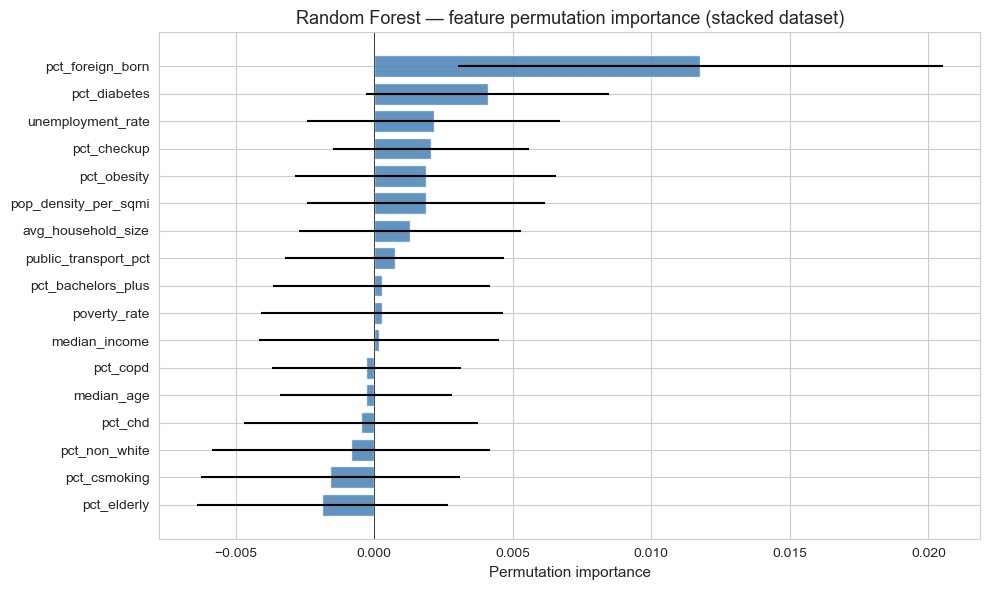

In [7]:
rf = RandomForestClassifier(n_estimators=500, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_scaled, y)
perm = permutation_importance(rf, X_scaled, y, n_repeats=30, random_state=42, n_jobs=-1)
perm_df = pd.DataFrame({
    'feature': CANDIDATE_FEATURES,
    'importance': perm.importances_mean,
    'std': perm.importances_std,
}).sort_values('importance', ascending=False)
perm_df['rank'] = perm_df['importance'].rank(ascending=False).astype(int)
print('RF permutation importance:')
print(perm_df.round(4).to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
sorted_df = perm_df.sort_values('importance')
ax.barh(sorted_df['feature'], sorted_df['importance'], xerr=sorted_df['std'],
        color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Permutation importance')
ax.set_title('Random Forest — feature permutation importance (stacked dataset)')
plt.tight_layout()
plt.show()

## 7. RFECV

In [8]:
rfe_est = LogisticRegressionCV(cv=cv, class_weight='balanced', max_iter=2000, random_state=42, scoring='average_precision')
rfecv = RFECV(estimator=rfe_est, cv=cv, scoring='average_precision', min_features_to_select=3, n_jobs=-1)
rfecv.fit(X_scaled, y)
rfecv_selected = X_scaled.columns[rfecv.support_].tolist()
rfecv_ranking = pd.Series(rfecv.ranking_, index=CANDIDATE_FEATURES).sort_values()
print(f'RFECV optimum: {rfecv.n_features_} features at PR-AUC={rfecv.cv_results_["mean_test_score"].max():.3f}')
print(f'Selected: {rfecv_selected}')

RFECV optimum: 4 features at PR-AUC=0.477
Selected: ['pct_bachelors_plus', 'pct_non_white', 'pct_foreign_born', 'pct_diabetes']


## 8. Multi-Method Consensus

In [9]:
all_ranks = pd.DataFrame(index=CANDIDATE_FEATURES)
all_ranks['pearson'] = filter_ranks['pearson_rank']
all_ranks['spearman'] = filter_ranks['spearman_rank']
all_ranks['mutual_info'] = filter_ranks['mi_rank']
all_ranks['lasso'] = lasso_rank
all_ranks['rf_perm'] = perm_df.set_index('feature')['rank']
all_ranks['rfecv'] = rfecv_ranking

n_features = len(CANDIDATE_FEATURES)
borda = (n_features + 1 - all_ranks).sum(axis=1)

TOP_K = 8  # broader than before because more features in candidate pool
ranking_methods = ['pearson', 'spearman', 'mutual_info', 'lasso', 'rf_perm']
top_k_count = (all_ranks[ranking_methods] <= TOP_K).sum(axis=1)
consensus = top_k_count >= 3

summary = pd.DataFrame({
    **{m: all_ranks[m] for m in ranking_methods + ['rfecv']},
    'borda': borda.astype(int),
    'top8_in_methods': top_k_count.astype(int),
    'consensus': consensus,
}).sort_values('borda', ascending=False)

print('Consensus selection:\n')
print(summary.to_string())

selected_demographic = summary[summary['consensus']].index.tolist()
print(f'\n=== {len(selected_demographic)} demographic features selected ===')
for f in selected_demographic:
    print(f'  ✅ {f}')
print(f'\n=== {(~consensus).sum()} dropped ===')
for f in summary[~summary['consensus']].index:
    print(f'  ❌ {f}')

Consensus selection:

                      pearson  spearman  mutual_info  lasso  rf_perm  rfecv  borda  top8_in_methods  consensus
pct_foreign_born            1         2            4      2        1      1     97                5       True
avg_household_size          2         1            9      1        7      6     82                4       True
pop_density_per_sqmi        5         4            6     10        6      4     73                4       True
median_income               6         9            2     10       11      3     67                2      False
pct_non_white               4         3            9     10       15      1     66                2      False
pct_diabetes                9         6           14     10        2      1     66                2      False
public_transport_pct        3         7           11     10        8      5     64                3       True
pct_elderly                 7         5            8     10       17      2     59        

## 9. Final Feature Set + Domain Overrides

Add `disease` and `state` as one-hot encoded categoricals (locked-in by domain knowledge).

In [10]:
import json

# Build final features
disease_dummies = pd.get_dummies(master['disease'], prefix='disease', drop_first=True).columns.tolist()
state_dummies = pd.get_dummies(master['state'], prefix='state', drop_first=True).columns.tolist()

final_features = selected_demographic + disease_dummies + state_dummies

print('=== Final feature set for ML models ===\n')
print(f'Demographic (consensus, {len(selected_demographic)}):')
for f in selected_demographic:
    print(f'  • {f}')
print(f'\nDisease dummies ({len(disease_dummies)}):')
for f in disease_dummies:
    print(f'  • {f}')
print(f'\nState dummies ({len(state_dummies)}):')
for f in state_dummies:
    print(f'  • {f}')

print(f'\nTotal: {len(final_features)} features')
print(f'Sample size: {len(master)}')
print(f'Ratio: {len(master) / len(final_features):.1f}:1')

# Export
out = {
    'demographic': selected_demographic,
    'disease_dummies': disease_dummies,
    'state_dummies': state_dummies,
    'all': final_features,
    'metadata': {
        'method': 'Multi-method consensus (top 8 in ≥ 3/5 ranking methods) + domain override',
        'n_obs': len(master),
        'n_features_final': len(final_features),
        'obs_to_features_ratio': round(len(master) / len(final_features), 2),
        'cv_strategy': 'StratifiedGroupKFold(n_splits=5, groups=fips)',
        'dataset_source': 'master_stacked.csv',
    },
    'rankings': summary.reset_index().rename(columns={'index': 'feature'}).to_dict(orient='records'),
}

with open(PROCESSED_DIR / 'selected_features.json', 'w') as f:
    json.dump(out, f, indent=2, default=str)
print(f'\n✅ Saved: {PROCESSED_DIR / "selected_features.json"}')

=== Final feature set for ML models ===

Demographic (consensus, 5):
  • pct_foreign_born
  • avg_household_size
  • pop_density_per_sqmi
  • public_transport_pct
  • pct_elderly

Disease dummies (2):
  • disease_FLU
  • disease_RSV

State dummies (3):
  • state_DE
  • state_NY
  • state_PA

Total: 10 features
Sample size: 357
Ratio: 35.7:1

✅ Saved: /Users/rocbarraket/Documents/ENGG2112/ENGG2112_Project/data/processed/selected_features.json


## 10. Summary

In [11]:
print('=== Feature Selection Summary ===\n')
print(f'Dataset: master_stacked.csv ({len(master)} rows × {len(CANDIDATE_FEATURES)} candidates)')
print(f'\nSelected demographic features: {len(selected_demographic)}')
for f in selected_demographic:
    print(f'  • {f}')
print(f'\nLocked-in dummies: {len(disease_dummies)} disease + {len(state_dummies)} state')
print(f'\nFinal feature count: {len(final_features)}')
print(f'Obs:features ratio: {len(master) / len(final_features):.1f}:1')
print(f'\n👉 Notebook 04 will use this feature set with StratifiedGroupKFold for evaluation.')

=== Feature Selection Summary ===

Dataset: master_stacked.csv (357 rows × 17 candidates)

Selected demographic features: 5
  • pct_foreign_born
  • avg_household_size
  • pop_density_per_sqmi
  • public_transport_pct
  • pct_elderly

Locked-in dummies: 2 disease + 3 state

Final feature count: 10
Obs:features ratio: 35.7:1

👉 Notebook 04 will use this feature set with StratifiedGroupKFold for evaluation.
